In [71]:
from skimage.morphology import erosion, dilation, opening, closing
from skimage.morphology import disk
import skimage.io as io
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.color import rgb2gray
import cv2

# From https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html
def plot_comparison(original, filtered, filter_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    io.show()

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


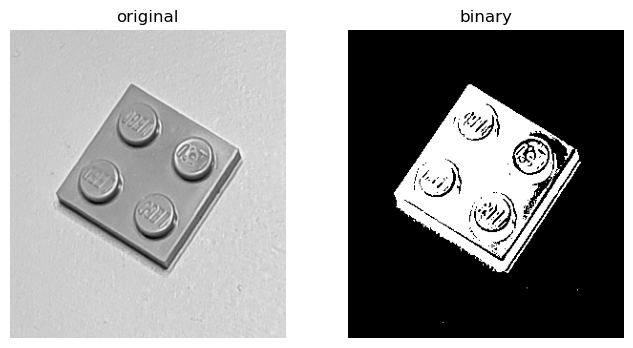

In [72]:
# 1.
img = io.imread('data/lego_5.png')
img_gray = rgb2gray(img)
thresh = threshold_otsu(img_gray)
binary = img_gray < thresh
plot_comparison(img_gray, binary, "binary")

[[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0]
 [0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0]
 [0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]]


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


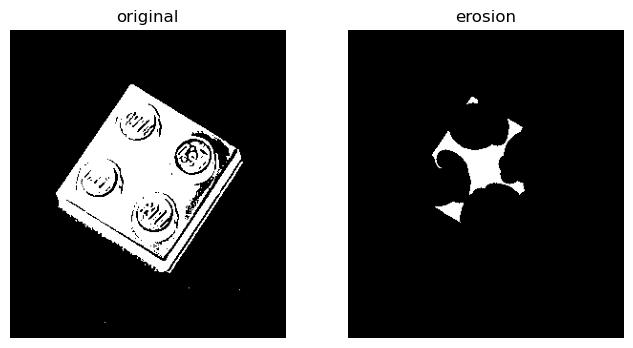

In [73]:
# 2.
footprint = disk(10)
# Check the size and shape of the structuring element
print(footprint)
eroded = erosion(binary, footprint)
plot_comparison(binary, eroded, 'erosion')

# Changing the size of the footprint will affect the erosion result:
# - A smaller footprint (e.g., disk(5)) will result in less erosion, preserving more of the original shapes.
# - A larger footprint (e.g., disk(15)) will result in more erosion, potentially removing smaller objects entirely.

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


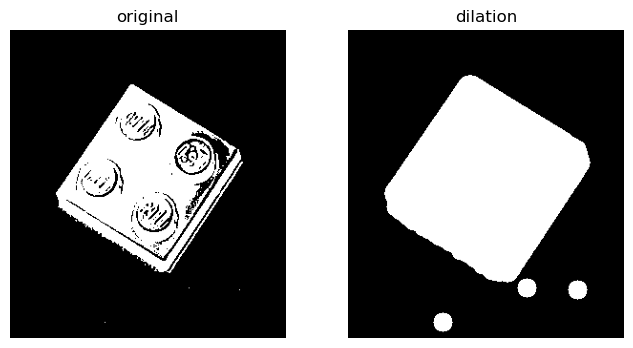

In [74]:
# 3.
dilated = dilation(binary, footprint)
plot_comparison(binary, dilated, 'dilation')

# changing the size of the footprint will affect the dilation result:
# - A smaller footprint (e.g., disk(5)) will result in less dilation, preserving more of the original shapes.
# - A larger footprint (e.g., disk(15)) will result in more dilation, potentially causing smaller objects to merge together.


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


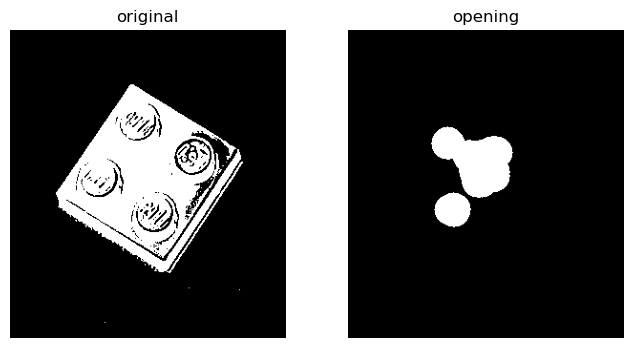

In [75]:
# 4.
footprint = disk(16)
opened = opening(binary, footprint)
plot_comparison(binary, opened, 'opening')

# Opening helps remove small objects and noise while preserving the overall shape of larger objects.
# The size of the footprint affects the extent of noise removal and shape preservation:
# - A smaller footprint (e.g., disk(5)) will remove less noise and preserve more details.
# - A larger footprint (e.g., disk(15)) will remove more noise but may also alter the shapes of larger objects.

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


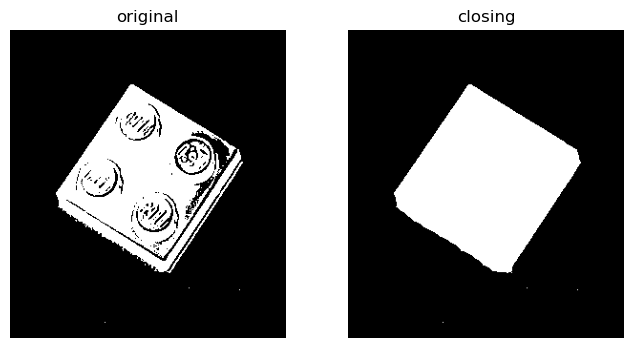

In [76]:
footprint = disk(16)
closed = closing(binary, footprint)
plot_comparison(binary, closed, 'closing')

# Closing helps remove small holes and gaps while preserving the overall shape of larger objects.
# The size of the footprint affects the extent of hole filling and shape preservation:
# - A smaller footprint (e.g., disk(5)) will fill less and preserve more details.
# - A larger footprint (e.g., disk(15)) will fill more but may also alter the shapes of larger objects.

In [77]:
import numpy as np

def compute_outline(bin_img):
    """
    Computes the outline of a binary image
    """
    footprint = disk(1)
    dilated = dilation(bin_img, footprint)
    outline = np.logical_xor(dilated, bin_img)
    return outline

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


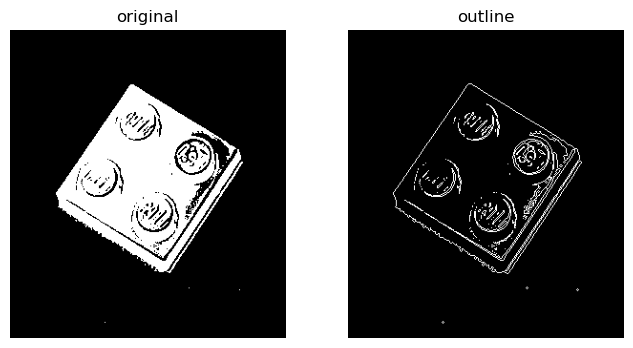

In [78]:
# 6. Compute the outline of the binary image and display it
outline = compute_outline(binary)
plot_comparison(binary, outline, 'outline')

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


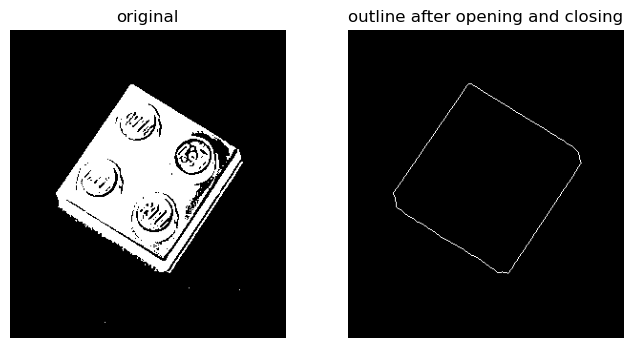

In [79]:
# 7.
opening_disk = disk(1)
closing_disk = disk(15)

opening_img = opening(binary, opening_disk)
closing_img = closing(opening_img, closing_disk)
outline_img = compute_outline(closing_img)
plot_comparison(binary, outline_img, 'outline after opening and closing')

# What do you observe and why does the result look like that?
# The opening operation is not big enough to remove all the small noise, 
# and the closing operation is too large, which causes some of the shapes to be altered significantly.

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


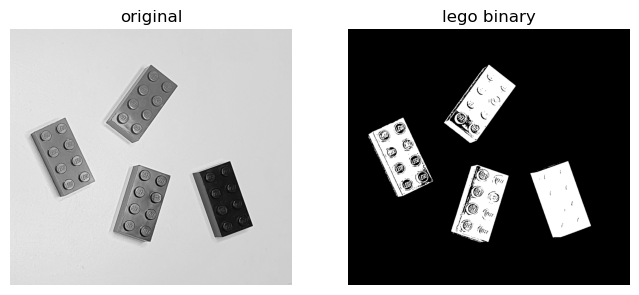

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


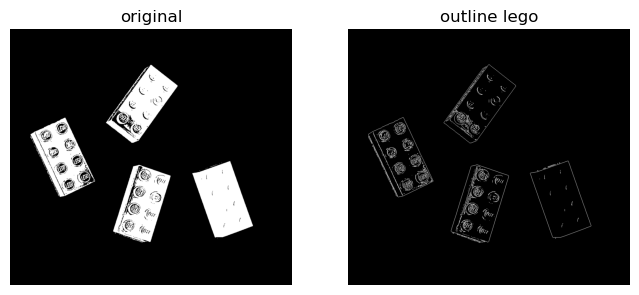

In [80]:
# 8. 
lego_img = io.imread('data/lego_7.png')
lego_gray = cv2.cvtColor(lego_img, cv2.COLOR_BGR2GRAY)
thresh = threshold_otsu(lego_gray)
lego_binary = lego_gray < thresh
plot_comparison(lego_gray, lego_binary, "lego binary")
outline_lego = compute_outline(lego_binary)
plot_comparison(lego_binary, outline_lego, 'outline lego')

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


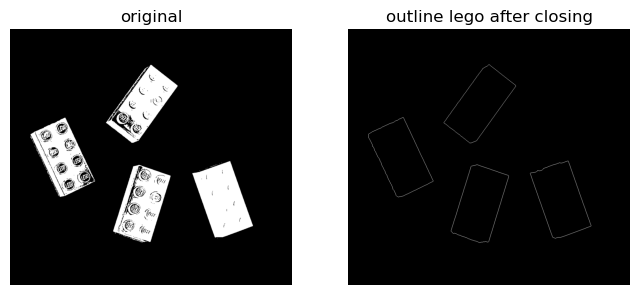

In [82]:
# 9. Try using the closing operations and find out which size of footprint that gives the desired result?
closing_disk = disk(10)
closing_img = closing(lego_binary, closing_disk)
outline_closing_lego = compute_outline(closing_img)
plot_comparison(lego_binary, outline_closing_lego, 'outline lego after closing')

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


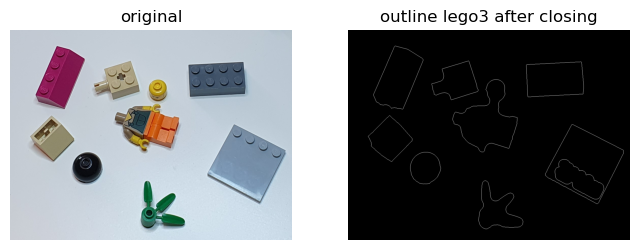

In [86]:
# 10. 
lego3 = io.imread('data/lego_3.png')
lego3_gray = cv2.cvtColor(lego3, cv2.COLOR_BGR2GRAY)
thresh = threshold_otsu(lego3_gray)
lego3_binary = lego3_gray < thresh

closing_disk = disk(20)
closing_img = closing(lego3_binary, closing_disk)
outline_closing_lego3 = compute_outline(closing_img)
plot_comparison(lego3, outline_closing_lego3, 'outline lego3 after closing')

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


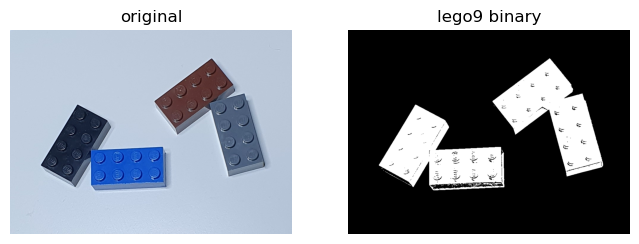

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


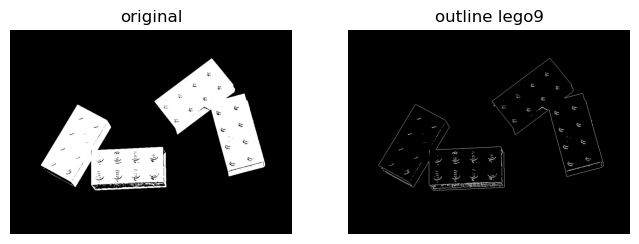

In [ ]:
# 11.
lego9 = io.imread('data/lego_9.png')
lego9_gray = cv2.cvtColor(lego9, cv2.COLOR_BGR2GRAY)
thresh = threshold_otsu(lego9_gray)
lego9_binary = lego9_gray < thresh
plot_comparison(lego9, lego9_binary, "lego9 binary")
outline_lego9 = compute_outline(lego9_binary)
plot_comparison(lego9_binary, outline_lego9, 'outline lego9')

# We can observe that lego bricks that are close together are detected as a single object.

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


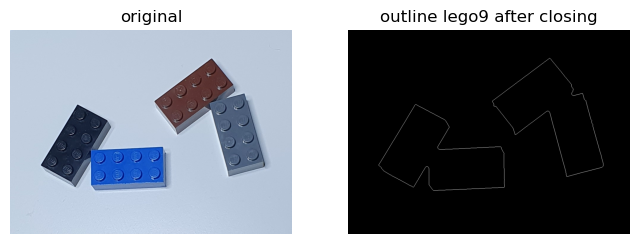

In [91]:
# 12. try to use closing to remove the noise holes
closing_disk = disk(7)
closing_img = closing(lego9_binary, closing_disk)
outline_closing_lego9 = compute_outline(closing_img)
plot_comparison(lego9, outline_closing_lego9, 'outline lego9 after closing')

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


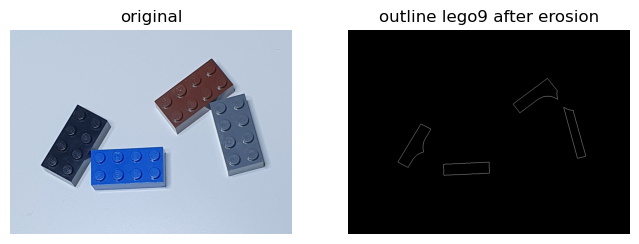

In [99]:
# 13. Now we will try to separate the objects. 
# Try using a erosion on the image that you repaired in exercise 12. 
# You should probably use a rather large footprint. 
# How large does it need to be in order to split the objects?
erosion_disk = disk(50)
eroded_img = erosion(closing_img, erosion_disk)
outline_eroded_lego9 = compute_outline(eroded_img)
plot_comparison(lego9, outline_eroded_lego9, 'outline lego9 after erosion')


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


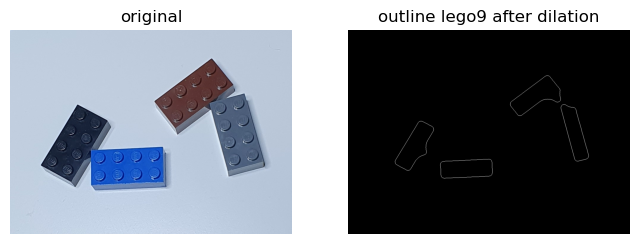

In [102]:
# 14. The objects lost a lot of size in the previous step. 
# Try to use dilate to make them larger. 
# How large can you make them before they start touching?
dilation_disk = disk(10)
dilated_img = dilation(eroded_img, dilation_disk)
outline_dilated_lego9 = compute_outline(dilated_img)
plot_comparison(lego9, outline_dilated_lego9, 'outline lego9 after dilation')


/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


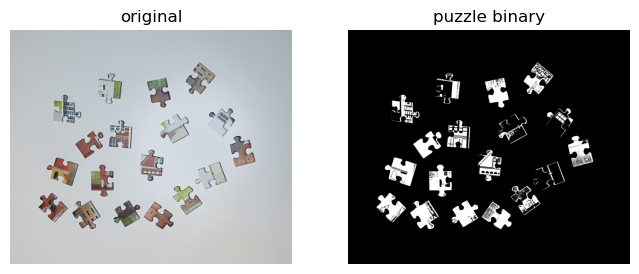

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


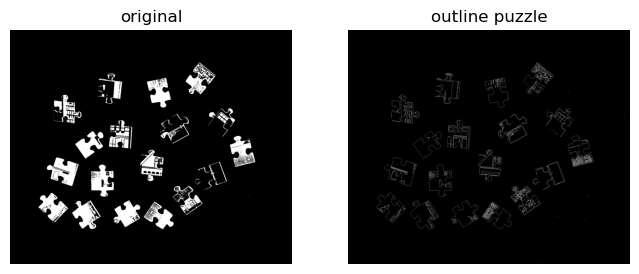

In [ ]:
# 15. Use the previosly used methods to compute a binary image from the puzzle photo. 
# What do you observe?
puzzle = io.imread('data/puzzle_pieces.png')
puzzle_gray = cv2.cvtColor(puzzle, cv2.COLOR_BGR2GRAY)
thresh = threshold_otsu(puzzle_gray)
puzzle_binary = puzzle_gray < thresh
plot_comparison(puzzle, puzzle_binary, "puzzle binary")
outline_puzzle = compute_outline(puzzle_binary)
plot_comparison(puzzle_binary, outline_puzzle, 'outline puzzle')
# We can observe that the pieces are not outlined properly

/var/folders/88/jkd1q3n525n9kd732z874nq00000gn/T/ipykernel_95056/1930262541.py:19: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


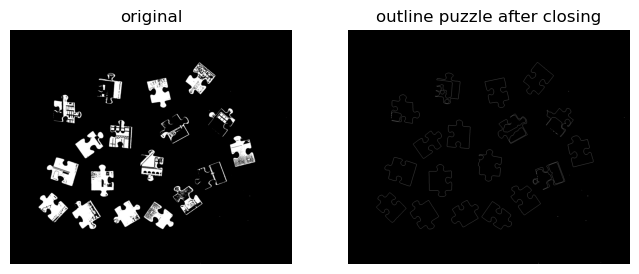

In [105]:
# 16. Try to use closing with a large footprint to clean the binary.
# Compute the outline. Do we have good outlines for all the pieces?
closing_disk = disk(15)
closing_img = closing(puzzle_binary, closing_disk)
outline_closing_puzzle = compute_outline(closing_img)
plot_comparison(puzzle_binary, outline_closing_puzzle, 'outline puzzle after closing')
